In [3]:
import pandas as pd
import re
import ftfy
import html
import unicodedata
from rapidfuzz import fuzz
from collections import Counter

# =====================================
# CONFIG
# =====================================

INPUT_PATH = "dataset/untidar_raw.csv"

OUTPUT_ANALYSIS = "dataset/break/dataset_step1_break_analysis1.csv"
OUTPUT_STATS = "dataset/break/break_stats.txt"

TEXT_COL = "Abstrak_Raw"

FUZZY_THRESHOLD = 80

# =====================================
# NORMALIZER
# =====================================

def normalize(text):

    if pd.isna(text):
        return ""

    text = str(text)

    text = ftfy.fix_text(text)
    text = html.unescape(text)
    text = unicodedata.normalize("NFKC", text)

    text = text.lower()

    text = re.sub(r"\s+", " ", text)

    return text.strip()


# =====================================
# DETECTORS
# =====================================



HEADER_RE = re.compile(
    r'^\s*["\']?\s*'
    r'(abstrak|abstract|intisari|ringkasan)'
    r'\s*$',
    re.I
)

KEYWORD_RE = re.compile(
    r'^(kata\s*kunci|keywords?|key\s*words?)\s*:',
    re.I
)

META_RE = re.compile(
    r'''
    undergraduate\s+thesis|
    bachelor\s+thesis|
    first\s+advisor|
    second\s+advisor|
    faculty\s+of|
    department|
    universitas|
    universiti|
    supervised\s+by|
    pembimbing|
    dosen\s+pembimbing|
    program\s+studi|
    fakultas
    ''',
    re.I | re.VERBOSE
)

YEAR_RE = re.compile(r"\b(19|20)\d{2}\b")


# =====================================
# FUZZY BLOCK CHECK
# =====================================

def is_metadata_match(block, row):

    block_norm = normalize(block)

    candidates = [
        row.get("Judul"),
        row.get("Penulis"),
        row.get("Fakultas"),
        row.get("Prodi")
    ]

    max_score = 0

    for c in candidates:

        if pd.isna(c):
            continue

        score = fuzz.partial_ratio(
            normalize(c),
            block_norm
        )

        max_score = max(max_score, score)

    return max_score >= FUZZY_THRESHOLD, max_score


# =====================================
# LOAD DATA
# =====================================

df = pd.read_csv(
    INPUT_PATH,
    sep="|",
    encoding="utf-8",
    on_bad_lines="skip"
)

print(f"Loaded {len(df):,} rows")

# =====================================
# ANALYSIS
# =====================================

rows = []

block_counter = Counter()

for idx, row in df.iterrows():

    doc_id = row.get("DocID")

    text = row.get(TEXT_COL)

    if pd.isna(text):
        continue

    text = str(text)

    blocks = [
        x.strip()
        for x in text.split("<BR>")
        if x.strip()
    ]

    for block_no, block in enumerate(blocks, start=1):

        block_norm = normalize(block)

        is_header = bool(
            HEADER_RE.match(block_norm)
        )

        is_keyword = bool(
            KEYWORD_RE.match(block_norm)
        )

        is_meta_pattern = bool(
            META_RE.search(block_norm)
        )

        is_year_only = bool(
            YEAR_RE.fullmatch(block_norm)
        )

        fuzzy_match, fuzzy_score = is_metadata_match(
            block,
            row
        )

        rows.append({

            "DocID": doc_id,

            "Block_No": block_no,

            "Block_Text": block,

            "Block_Length": len(block),

            "Word_Count": len(block.split()),

            "Is_Header": is_header,

            "Is_Keyword": is_keyword,

            "Is_MetadataPattern": is_meta_pattern,

            "Is_MetadataMatch": fuzzy_match,

            "Metadata_Score": fuzzy_score,

            "Is_YearOnly": is_year_only
        })

        block_counter[block_norm] += 1

    if idx % 500 == 0:
        print(
            f"{idx:,}/{len(df):,}"
        )

# =====================================
# SAVE ANALYSIS
# =====================================

analysis_df = pd.DataFrame(rows)

analysis_df.to_csv(
    OUTPUT_ANALYSIS,
    index=False,
    encoding="utf-8"
)

print(
    f"\nSaved:\n{OUTPUT_ANALYSIS}"
)

# =====================================
# TOP BLOCKS
# =====================================

top_blocks = pd.DataFrame(
    block_counter.most_common(200),
    columns=[
        "Block_Text",
        "Frequency"
    ]
)

# =====================================
# STATS
# =====================================

with open(
    OUTPUT_STATS,
    "w",
    encoding="utf-8"
) as f:

    f.write("==== BREAK ANALYSIS ====\n\n")

    f.write(
        f"Rows: {len(df):,}\n"
    )

    f.write(
        f"Blocks: {len(analysis_df):,}\n\n"
    )

    f.write(
        f"Headers: {analysis_df['Is_Header'].sum():,}\n"
    )

    f.write(
        f"Keywords: {analysis_df['Is_Keyword'].sum():,}\n"
    )

    f.write(
        f"MetadataPattern: {analysis_df['Is_MetadataPattern'].sum():,}\n"
    )

    f.write(
        f"MetadataMatch: {analysis_df['Is_MetadataMatch'].sum():,}\n\n"
    )

    f.write(
        "===== TOP 200 BLOCKS =====\n\n"
    )

    for _, r in top_blocks.iterrows():

        f.write(
            f"[{r['Frequency']}] "
            f"{r['Block_Text'][:500]}\n"
        )

print(
    f"Saved:\n{OUTPUT_STATS}"
)

# =====================================
# QUICK SUMMARY
# =====================================

print("\n===== SUMMARY =====")

print(
    "Headers:",
    analysis_df["Is_Header"].sum()
)

print(
    "Keywords:",
    analysis_df["Is_Keyword"].sum()
)

print(
    "MetadataPattern:",
    analysis_df["Is_MetadataPattern"].sum()
)

print(
    "MetadataMatch:",
    analysis_df["Is_MetadataMatch"].sum()
)

print(
    "\nTop recurring blocks:"
)

print(
    top_blocks.head(20)
)

Loaded 7,621 rows
0/7,621
500/7,621
1,000/7,621
1,500/7,621
2,000/7,621
2,500/7,621
3,000/7,621
3,500/7,621
4,000/7,621
4,500/7,621
5,000/7,621
5,500/7,621
6,000/7,621
6,500/7,621
7,000/7,621
7,500/7,621

Saved:
dataset/break/dataset_step1_break_analysis1.csv
Saved:
dataset/break/break_stats.txt

===== SUMMARY =====
Headers: 3737
Keywords: 3353
MetadataPattern: 1366
MetadataMatch: 5786

Top recurring blocks:
                                           Block_Text  Frequency
0                                             abstrak       2587
1                            tidak tersedia deskripsi       1065
2                                            abstract        558
3                                            intisari        538
4                                           abstraksi        112
5                                   2. hipotesa minor        101
6                                   1. hipotesa mayor         94
7                                  1. hipotesa mayor.         61
8  

In [4]:
import pandas as pd
import re
import ftfy
import html
import unicodedata
from rapidfuzz import fuzz

# ==========================================
# CONFIG
# ==========================================

INPUT_PATH = "dataset/untidar_raw.csv"
OUTPUT_PATH = "dataset/dataset_step2_cleaned.csv"

TEXT_COL = "Abstrak_Raw"
FUZZY_THRESHOLD = 95

# ==========================================
# REGEX
# ==========================================

EMAIL_RE = re.compile(r"[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+")

HEADER_WORDS = {
    "abstrak", "abstract", "intisari",
    "ringkasan", "abstraksi", "abstrac", "abstrack"
}

KEYWORD_RE = re.compile(r"^(kata\s*kunci|keywords?|key\s*words?)\s*:", re.I)

METADATA_RE = re.compile(
    r"""
    universitas|fakultas|program\s*studi|jurusan|
    undergraduate|bachelor|thesis|skripsi|
    advisor|pembimbing|faculty|department
    """,
    re.I | re.X
)

SHORT_TRASH_RE = re.compile(r"^(\d+|[ivxlcdm]+|\-|\.|…)$", re.I)

# ==========================================
# SUPERVISOR DETECTION (BRUTE FORCE CORE)
# ==========================================

SUPERVISOR_KEYWORD_RE = re.compile(
    r"(dibimbing\s+oleh|pembimbing|dosen\s+pembimbing|advisor)",
    re.I
)

SUPERVISOR_BLOCK_BRUTE_RE = re.compile(
    r"""
    (dibimbing\s+oleh|pembimbing|dosen\s+pembimbing|advisor)
    .*?
    ([A-Z][a-z]+(?:\s+[A-Z][a-z]+){1,}\s*,\s*(S\.|M\.))
    .*?
    (dan|&)
    .*?
    ([A-Z][a-z]+(?:\s+[A-Z][a-z]+){1,}\s*,\s*(S\.|M\.))
    """,
    re.I | re.X
)

def is_supervisor_heavy_block(text: str) -> bool:
    if not isinstance(text, str):
        return False

    has_titles = len(re.findall(r",\s*(S\.|M\.)", text)) >= 2
    has_and = " dan " in text.lower()

    return has_titles and has_and

# ==========================================
# CLEANING HELPERS
# ==========================================
# Drop Duplicate
# Simpan baris terakhir

def normalize(text):
    if not isinstance(text, str):
        return ""

    text = ftfy.fix_text(text)
    text = html.unescape(text)
    text = unicodedata.normalize("NFKC", text)

    text = text.lower()
    text = re.sub(r"\s+", " ", text)

    return text.strip()


def strip_supervisor_only(text: str) -> str:
    if not isinstance(text, str):
        return ""

    return re.sub(
        r"(dibimbing\s+oleh|pembimbing\s*[:\-]|dosen\s+pembimbing|advisor)\s*",
        "",
        text,
        flags=re.I
    ).strip()


def strip_academic_names(text: str) -> str:
    return re.sub(
        r"[A-Z][a-z]+(?:\s+[A-Z][a-z]+)*,\s*(S\.|M\.)[A-Za-z\.,\s]*",
        "",
        text
    ).strip()


def clean_block_prefix(block: str) -> str:
    if not isinstance(block, str):
        return ""

    block = EMAIL_RE.sub(" ", block)

    block = re.sub(
        r"^\s*(abstrak|abstract|intisari|ringkasan)\s*[:\-]?\s*",
        "",
        block,
        flags=re.I
    )

    block = re.sub(r"^[A-Z\s\.,]{5,}\.\s*", "", block)

    return re.sub(r"\s+", " ", block).strip()

# ==========================================
# FUZZY METADATA
# ==========================================

def is_fuzzy_metadata(block, noise_list):
    b = normalize(block)

    for n in noise_list:
        if isinstance(n, str):
            if fuzz.partial_ratio(normalize(n), b) >= FUZZY_THRESHOLD:
                return True
    return False


def build_noise(row):
    return [
        str(row[c])
        for c in ["Judul", "Penulis", "Fakultas", "Prodi"]
        if c in row and pd.notna(row[c])
    ]

# ==========================================
# SENTENCE COUNT
# ==========================================

def count_sentences(text):
    if not isinstance(text, str):
        return 0
    return len([s for s in re.split(r"[.!?]+", text) if s.strip()])

# ==========================================
# MAIN CLEANER
# ==========================================

def clean_row(row):

    text = row.get(TEXT_COL)

    if not isinstance(text, str):
        return pd.Series({
            "Paragraf": "",
            "Keyword_Text": "",
            "Has_Keyword": False,
            "Removed_Header": 0,
            "Removed_Keyword": 0,
            "Removed_Metadata": 0,
            "Removed_Fuzzy": 0,
            "Removed_Garbage": 0,
            "BR_Count": 0,
            "Word_Count": 0,
            "Sentence_Count": 0
        })

    text = ftfy.fix_text(text)
    text = html.unescape(text)
    text = unicodedata.normalize("NFKC", text)

    # quote setelah separator
    text = re.sub(r'(?<=\|)\s*"', '', text)

    # quote sebelum separator
    text = re.sub(r'"\s*(?=\|)', '', text)

    blocks = [
        clean_block_prefix(b.strip())
        for b in text.split("<BR>")
        if b.strip()
    ]

    noise = build_noise(row)

    clean_blocks = []
    keywords = []

    removed_header = 0
    removed_keyword = 0
    removed_metadata = 0
    removed_fuzzy = 0
    removed_garbage = 0

    for b in blocks:

        # =========================
        # SAFE EDIT LAYER
        # =========================

        b = strip_supervisor_only(b)
        b = strip_academic_names(b)

        # BRUTE FORCE SUPERVISOR KILL
        if SUPERVISOR_BLOCK_BRUTE_RE.search(b) or is_supervisor_heavy_block(b):
            removed_metadata += 1
            continue

        b_norm = normalize(b)

        if b_norm in {"tidak tersedia deskripsi", "tidak ada abstrak", "-", "...", "."}:
            removed_garbage += 1
            continue

        if b_norm in HEADER_WORDS:
            removed_header += 1
            continue

        if KEYWORD_RE.match(b):
            keywords.append(b)
            removed_keyword += 1
            continue

        if METADATA_RE.search(b):
            removed_metadata += 1
            continue

        if is_fuzzy_metadata(b, noise):
            removed_fuzzy += 1
            continue

        if SHORT_TRASH_RE.match(b_norm):
            removed_garbage += 1
            continue

        if len(b.strip()) < 5:
            removed_garbage += 1
            continue

        clean_blocks.append(b)

    paragraf = " ".join(clean_blocks)
    paragraf = re.sub(r"\s+", " ", paragraf).strip()

    return pd.Series({
        "Paragraf": paragraf,
        "Keyword_Text": " | ".join(keywords),
        "Has_Keyword": len(keywords) > 0,

        "Removed_Header": removed_header,
        "Removed_Keyword": removed_keyword,
        "Removed_Metadata": removed_metadata,
        "Removed_Fuzzy": removed_fuzzy,
        "Removed_Garbage": removed_garbage,

        "BR_Count": len(blocks),
        "Word_Count": len(paragraf.split()),
        "Sentence_Count": count_sentences(paragraf)
    })

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv(INPUT_PATH, sep="|", encoding="utf-8", on_bad_lines="skip")

df = df[
    ~df[TEXT_COL].fillna("").str.lower().str.contains("tidak tersedia deskripsi", na=False)
].copy()

# ==========================================
# PROCESS
# ==========================================

cleaned = df.apply(clean_row, axis=1)
df = pd.concat([df, cleaned], axis=1)

df = df[df["Word_Count"] >= 20].reset_index(drop=True)



# ==========================================
# FORMAT OUTPUT
# ==========================================

df = df.drop(columns=[TEXT_COL])

cols = list(df.columns)
cols.remove("Paragraf")
cols.insert(cols.index("DocID") + 1, "Paragraf")

df = df[cols]

# ==========================================
# SAVE
# ==========================================

df.to_csv(OUTPUT_PATH, sep="|", index=False, encoding="utf-8")

print("CLEANING COMPLETE")
print("Rows:", len(df))
print("Avg words:", df["Word_Count"].mean())

CLEANING COMPLETE
Rows: 5298
Avg words: 217.8463571158928


In [5]:
df.drop_duplicates(subset=["Paragraf"], inplace=True)
df.to_csv(OUTPUT_PATH, sep="|", index=False, encoding="utf-8")

In [6]:
df["WPS"] = df["Word_Count"] / df["Sentence_Count"]

df["flag_long_doc"] = df["Word_Count"] > 500
df["flag_short_doc"] = df["Word_Count"] < 50

df["flag_long_sentence"] = df["WPS"] > 40

BOUNDARY_ERROR_RE = re.compile(
    r'(?<![A-Z])\.([A-Z][a-z])'
)

df["boundary_errors"] = (
    df["Paragraf"]
    .str.count(BOUNDARY_ERROR_RE)
)

print(df["boundary_errors"].describe())


df.sort_values(
    "boundary_errors",
    ascending=False
)[
    ["DocID","boundary_errors","Paragraf"]
].head(20)

count    5277.000000
mean        0.069926
std         0.480712
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        14.000000
Name: boundary_errors, dtype: float64


,DocID,boundary_errors,Paragraf
1361,16817,14,"Saat ini,pelayanan publik masih berkualitas re..."
1696,17449,8,"Dalam rangka mewujudkan Tujuan Nasional, Pemer..."
1691,17444,8,Penelitian dilakukan dengan memilih lokasi pen...
897,16095,8,Pada era globalisasi saat ini perkembangan dun...
534,15588,7,Seperti telah dikemukakan dalam latar belakang...
1688,17441,6,"Dalam organisasi, baik swasta maupun pemerinta..."
1690,17443,6,Pembangunan merupakan rangkaian usaha pertumbu...
1692,17445,6,"Sejak kemerdekaan tanggal 17 Agustus 1945, neg..."
1100,16458,6,Putusan Pengadilan Negeri Magelang Nomor 3/Pid...
3654,19874,6,Perkembangan teknologi informasi telah mendoro...


In [7]:
df["flag_wps_50"] = df["WPS"] > 50

import re

def longest_sentence_words(text):

    sents = re.split(r'[.!?]+', str(text))

    if not sents:
        return 0

    return max(
        len(s.split())
        for s in sents
        if s.strip()
    )

df["max_sentence_words"] = (
    df["Paragraf"]
    .apply(longest_sentence_words)
)

df["max_sentence_words"].describe()

count    5277.000000
mean       40.556756
std        16.716804
min        13.000000
25%        30.000000
50%        36.000000
75%        46.000000
max       183.000000
Name: max_sentence_words, dtype: float64

<Axes: xlabel='max_sentence_words', ylabel='Count'>

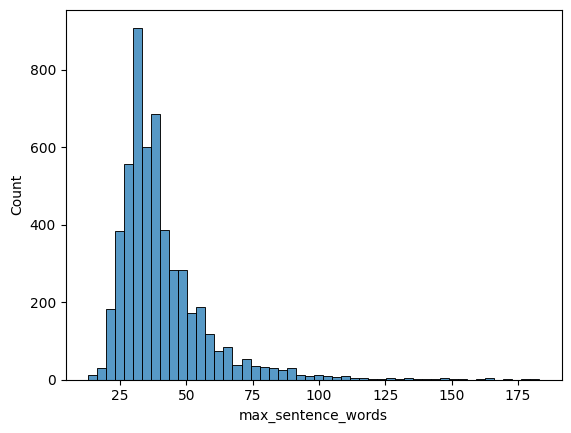

In [8]:
import seaborn as sns
sns.histplot(
    df["max_sentence_words"],
    bins=50
)

In [9]:
import pandas as pd
import stanza

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("dataset/dataset_step2_cleaned.csv", sep="|")

# =========================
# STANZA PIPELINE
# =========================
nlp = stanza.Pipeline(
    "id",
    processors="tokenize,lemma,pos,depparse",
    use_gpu=True,
    batch_size=64
)

# =========================
# AUDIT FUNCTION
# =========================
def stanza_audit(text):

    if not isinstance(text, str) or len(text.strip()) == 0:
        return {
            "n_sent": 0,
            "max_len": 0,
            "avg_len": 0,
            "no_verb_sent": 0
        }

    doc = nlp(text)
    sentences = doc.sentences

    if len(sentences) == 0:
        return {
            "n_sent": 0,
            "max_len": 0,
            "avg_len": 0,
            "no_verb_sent": 0
        }

    return {
        "n_sent": len(sentences),
        "max_len": max(len(s.words) for s in sentences),
        "avg_len": sum(len(s.words) for s in sentences) / len(sentences),
        "no_verb_sent": sum(
            1 for s in sentences
            if not any(w.upos == "VERB" for w in s.words)
        )
    }

# =========================
# RUN AUDIT
# =========================
results = df["Paragraf"].apply(stanza_audit).apply(pd.Series)

df_audit = pd.concat([df[["DocID"]], results], axis=1)

# =========================
# ADD FLAGS (IMPORTANT)
# =========================
df_audit["flag_long_sentence"] = df_audit["max_len"] > 80
df_audit["flag_no_verb"] = df_audit["no_verb_sent"] > 0
df_audit["flag_single_sentence"] = df_audit["n_sent"] == 1

# suspicious if 1 sentence but long text
df_audit["flag_boundary_error"] = (
    (df_audit["n_sent"] == 1) &
    (df_audit["max_len"] > 60)
)

# =========================
# SAVE CSV
# =========================
OUTPUT_PATH = "audit_stanza_docid.csv"

df_audit.to_csv(
    OUTPUT_PATH,
    index=False,
    sep="|"
)

print("AUDIT DONE ✔")
print("Saved to:", OUTPUT_PATH)
print(df_audit.head())

2026-06-20 11:22:50 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2026-06-20 11:22:52 INFO: Downloaded file to C:\Users\Danang ARA\stanza_resources\resources.json
2026-06-20 11:22:52 WARNING: Language id package default expects mwt, which has been added
2026-06-20 11:22:53 INFO: Loading these models for language: id (Indonesian):
| Processor | Package      |
----------------------------
| tokenize  | gsd          |
| mwt       | gsd          |
| pos       | gsd_charlm   |
| lemma     | gsd_nocharlm |
| depparse  | gsd_charlm   |

2026-06-20 11:22:53 INFO: Using device: cuda
2026-06-20 11:22:53 INFO: Loading: tokenize
2026-06-20 11:22:53 INFO: Loading: mwt
2026-06-20 11:22:53 INFO: Loading: pos
2026-06-20 11:22:54 INFO: Loading: lemma
2026-06-20 11:22:54 INFO: Loading: depparse
2026-06-20 11:22:55 INFO: Done loading processors!


AUDIT DONE ✔
Saved to: audit_stanza_docid.csv
   DocID  n_sent  max_len    avg_len  no_verb_sent  flag_long_sentence  \
0  15001    13.0     32.0  17.000000           0.0               False   
1  15002    13.0     82.0  35.615385          13.0                True   
2  15003    11.0     51.0  22.090909           0.0               False   
3  15004    14.0     39.0  25.000000           7.0               False   
4  15005     8.0     34.0  21.250000           0.0               False   

   flag_no_verb  flag_single_sentence  flag_boundary_error  
0         False                 False                False  
1          True                 False                False  
2         False                 False                False  
3          True                 False                False  
4         False                 False                False  


In [10]:
import pandas as pd
import numpy as np

# ==========================================
# LOAD AUDIT RESULT
# ==========================================

df = pd.read_csv(
    "audit_stanza_docid.csv",
    sep="|"
)

# ==========================================
# COMPONENT SCORES
# ==========================================

# Sentence length health
df["sentence_score"] = (
    1 - np.minimum(df["max_len"] / 120, 1)
)

# Verb completeness
df["verb_score"] = (
    1 - (
        df["no_verb_sent"] /
        np.maximum(df["n_sent"], 1)
    )
)

# Boundary quality
df["boundary_score"] = np.where(
    df["flag_boundary_error"],
    0.30,
    1.00
)

# Segmentation quality
df["seg_score"] = np.where(
    (df["flag_single_sentence"]) &
    (df["max_len"] > 60),
    0.40,
    1.00
)

# ==========================================
# FINAL DQS
# ==========================================

df["DQS"] = (
    0.30 * df["sentence_score"] +
    0.30 * df["verb_score"] +
    0.30 * df["boundary_score"] +
    0.10 * df["seg_score"]
)

df["DQS"] = df["DQS"].clip(0, 1)

# ==========================================
# LABEL
# ==========================================

conditions = [
    df["DQS"] >= 0.85,
    df["DQS"] >= 0.70,
    df["DQS"] >= 0.50
]

choices = [
    "EXCELLENT",
    "GOOD",
    "FAIR"
]

df["DQS_Label"] = np.select(
    conditions,
    choices,
    default="POOR"
)

# ==========================================
# SAVE
# ==========================================

df.to_csv(
    "audit_stanza_dqs.csv",
    sep="|",
    index=False
)

print("\n===== DQS SUMMARY =====")
print(df["DQS"].describe())

print("\n===== LABEL DISTRIBUTION =====")
print(df["DQS_Label"].value_counts())

print("\nSaved:")
print("audit_stanza_dqs.csv")


===== DQS SUMMARY =====
count    5277.000000
mean        0.818607
std         0.122049
min         0.400000
25%         0.805000
50%         0.865000
75%         0.897500
max         0.960000
Name: DQS, dtype: float64

===== LABEL DISTRIBUTION =====
DQS_Label
EXCELLENT    3099
GOOD         1395
FAIR          634
POOR          149
Name: count, dtype: int64

Saved:
audit_stanza_dqs.csv


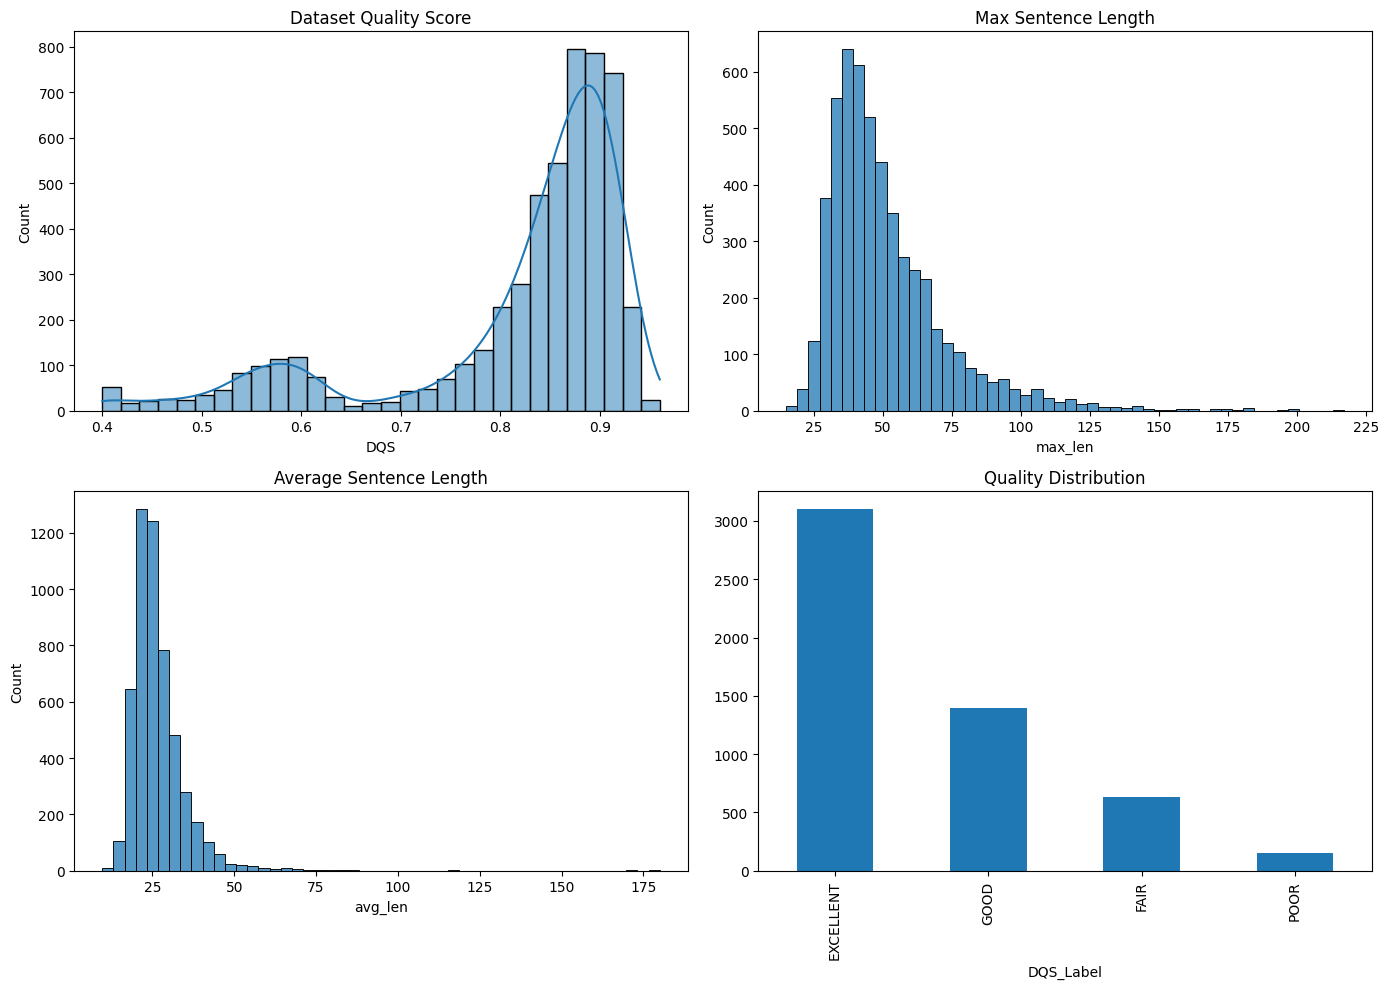


===== WORST 20 DOCUMENTS =====


,DocID,DQS,n_sent,max_len,avg_len,no_verb_sent
18,15020,0.4,4.0,145.0,64.750000,4.0
91,15100,0.4,9.0,123.0,31.333333,9.0
489,15538,0.4,15.0,173.0,45.266667,15.0
56,15062,0.4,6.0,135.0,53.833333,6.0
487,15536,0.4,8.0,172.0,52.125000,8.0
433,15474,0.4,4.0,148.0,61.250000,4.0
472,15519,0.4,5.0,137.0,68.000000,5.0
474,15521,0.4,7.0,163.0,56.285714,7.0
102,15111,0.4,8.0,158.0,42.375000,8.0
115,15124,0.4,9.0,121.0,31.444444,9.0


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "audit_stanza_dqs.csv",
    sep="|"
)

# ==========================================
# DASHBOARD
# ==========================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,10)
)

# ------------------------
# DQS
# ------------------------

sns.histplot(
    df["DQS"],
    bins=30,
    kde=True,
    ax=axes[0,0]
)

axes[0,0].set_title(
    "Dataset Quality Score"
)

# ------------------------
# Sentence Length
# ------------------------

sns.histplot(
    df["max_len"],
    bins=50,
    ax=axes[0,1]
)

axes[0,1].set_title(
    "Max Sentence Length"
)

# ------------------------
# Average Length
# ------------------------

sns.histplot(
    df["avg_len"],
    bins=50,
    ax=axes[1,0]
)

axes[1,0].set_title(
    "Average Sentence Length"
)

# ------------------------
# Quality Labels
# ------------------------

df["DQS_Label"].value_counts().plot(
    kind="bar",
    ax=axes[1,1]
)

axes[1,1].set_title(
    "Quality Distribution"
)

plt.tight_layout()
plt.show()

# ==========================================
# TOP BAD DOCS
# ==========================================

print("\n===== WORST 20 DOCUMENTS =====")

display(
    df.sort_values(
        "DQS"
    )[
        [
            "DocID",
            "DQS",
            "n_sent",
            "max_len",
            "avg_len",
            "no_verb_sent"
        ]
    ].head(20)
)

In [12]:
bad = df.sort_values("DQS").head(50)

bad[[
    "DocID",
    "DQS",
    "n_sent",
    "max_len",
    "avg_len",
    "no_verb_sent"
]]

,DocID,DQS,n_sent,max_len,avg_len,no_verb_sent
18,15020,0.4000,4.0,145.0,64.750000,4.0
91,15100,0.4000,9.0,123.0,31.333333,9.0
489,15538,0.4000,15.0,173.0,45.266667,15.0
56,15062,0.4000,6.0,135.0,53.833333,6.0
487,15536,0.4000,8.0,172.0,52.125000,8.0
433,15474,0.4000,4.0,148.0,61.250000,4.0
472,15519,0.4000,5.0,137.0,68.000000,5.0
474,15521,0.4000,7.0,163.0,56.285714,7.0
102,15111,0.4000,8.0,158.0,42.375000,8.0
115,15124,0.4000,9.0,121.0,31.444444,9.0


In [13]:
#penyebab eror 
bad = df[df["DQS"] < 0.5]

print(bad["flag_boundary_error"].mean())
print(bad["flag_no_verb"].mean())
print(bad["flag_single_sentence"].mean())

0.020134228187919462
0.9798657718120806
0.020134228187919462


In [17]:
# verifikasi kualitas tanda baca
bad = df[df["DQS"] < 0.5]

print(
    bad["max_len"].describe()
)

count    149.000000
mean     112.221477
std       28.373676
min       81.000000
25%       92.000000
50%      104.000000
75%      124.000000
max      217.000000
Name: max_len, dtype: float64


In [18]:
import pandas as pd
import re

df = pd.read_csv("dataset/dataset_step2_cleaned.csv", sep="|")

# =========================
# PATTERN UTAMA
# =========================

MERGE_PATTERN = re.compile(
    r"\.[A-ZА-ЯA-Z]"  # titik langsung huruf besar
)

def detect_merge(text):
    if not isinstance(text, str):
        return 0

    return len(MERGE_PATTERN.findall(text))


def has_merge(text):
    return detect_merge(text) > 0

# =========================
# APPLY
# =========================

df["merge_error_count"] = df["Paragraf"].apply(detect_merge)
df["flag_merge_error"] = df["merge_error_count"] > 0

print(df["flag_merge_error"].value_counts())

flag_merge_error
False    4990
True      287
Name: count, dtype: int64


In [19]:
import stanza

nlp = stanza.Pipeline(
    "id",
    processors="tokenize,lemma,pos,depparse",
    use_gpu=True
)

def stanza_sentence_count(text):
    if not isinstance(text, str):
        return 0

    doc = nlp(text)
    return len(doc.sentences)

# =========================
# APPLY SAMPLE (biar cepat)
# =========================

sample = df[df["flag_merge_error"] == True].head(200).copy()

sample["stanza_sent"] = sample["Paragraf"].apply(stanza_sentence_count)

# kasus penting:
# merge error tapi stanza cuma 1 sentence
sample["confirmed_merge"] = (
    (sample["merge_error_count"] > 0) &
    (sample["stanza_sent"] == 1)
)

print("CONFIRMED MERGE CASES:", sample["confirmed_merge"].mean())
print(sample[["DocID","merge_error_count","stanza_sent"]].head())

2026-06-20 11:49:05 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2026-06-20 11:49:05 INFO: Downloaded file to C:\Users\Danang ARA\stanza_resources\resources.json
2026-06-20 11:49:05 WARNING: Language id package default expects mwt, which has been added
2026-06-20 11:49:06 INFO: Loading these models for language: id (Indonesian):
| Processor | Package      |
----------------------------
| tokenize  | gsd          |
| mwt       | gsd          |
| pos       | gsd_charlm   |
| lemma     | gsd_nocharlm |
| depparse  | gsd_charlm   |

2026-06-20 11:49:06 INFO: Using device: cuda
2026-06-20 11:49:06 INFO: Loading: tokenize
2026-06-20 11:49:06 INFO: Loading: mwt
2026-06-20 11:49:06 INFO: Loading: pos
2026-06-20 11:49:07 INFO: Loading: lemma
2026-06-20 11:49:07 INFO: Loading: depparse
2026-06-20 11:49:08 INFO: Done loading processors!


CONFIRMED MERGE CASES: 0.0
     DocID  merge_error_count  stanza_sent
21   15023                  1            5
23   15026                  1           11
50   15053                  1            7
64   15070                  1            9
108  15117                  2            9


Rule-based punctuation heuristics overestimate sentence boundary errors, while neural sentence segmentation models (Stanza) demonstrate robustness against missing whitespace after period in Indonesian academic texts

In [23]:
import pandas as pd
import nltk

# pastikan nltk punkt sudah diunduh
nltk.download("punkt")

# contoh dataframe
df = pd.read_csv("dataset/dataset_step2_cleaned.csv", sep="|")

# hitung jumlah kata per dokumen
df["Word_Count"] = (
    df["Paragraf"]
    .str.split()
    .str.len()
)

# hitung jumlah kalimat per dokumen
df["Sentence_Count"] = df["Paragraf"].apply(
    lambda x: len(nltk.sent_tokenize(str(x)))
)

# total kata dan kalimat
total_words = df["Word_Count"].sum()
total_sentences = df["Sentence_Count"].sum()

print("\n===== CORPUS SIZE =====")
print(f"Dokumen   : {len(df):,}")
print(f"Kalimat   : {total_sentences:,}")
print(f"Kata      : {total_words:,}")
print(f"Rata kata/kalimat : {total_words/total_sentences:.2f}")

# hitung rata-rata kata per kalimat per dokumen
df["Words_Per_Sentence"] = (
    df["Word_Count"] /
    df["Sentence_Count"].clip(lower=1)
)

print("\n===== SENTENCE STATS =====")
print(df["Sentence_Count"].describe())
print(df["Sentence_Count"].quantile([0.01,0.05,0.25,0.50,0.75,0.95,0.99]))

print("\n===== WORDS PER SENTENCE =====")
print(df["Words_Per_Sentence"].describe())


[nltk_data] Downloading package punkt to C:\Users\Danang
[nltk_data]     ARA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!



===== CORPUS SIZE =====
Dokumen   : 5,277
Kalimat   : 56,599
Kata      : 1,150,032
Rata kata/kalimat : 20.32

===== SENTENCE STATS =====
count    5277.000000
mean       10.725602
std         5.688773
min         1.000000
25%         7.000000
50%        10.000000
75%        12.000000
max        64.000000
Name: Sentence_Count, dtype: float64
0.01     3.0
0.05     5.0
0.25     7.0
0.50    10.0
0.75    12.0
0.95    21.0
0.99    35.0
Name: Sentence_Count, dtype: float64

===== WORDS PER SENTENCE =====
count    5277.000000
mean       21.975047
std         7.560860
min         7.750000
25%        17.833333
50%        20.619048
75%        24.333333
max       165.000000
Name: Words_Per_Sentence, dtype: float64


In [24]:
outliers = df[df["Sentence_Count"] > 35].copy()

print("OUTLIER COUNT:", len(outliers))

OUTLIER COUNT: 47


In [25]:
print(outliers[[
    "Word_Count",
    "Sentence_Count",
    "Words_Per_Sentence"
]].describe())

       Word_Count  Sentence_Count  Words_Per_Sentence
count   47.000000       47.000000           47.000000
mean   638.978723       42.234043           15.155191
std    139.043704        6.276986            2.673836
min    434.000000       36.000000           10.571429
25%    531.500000       38.000000           13.179688
50%    608.000000       40.000000           14.767442
75%    754.000000       45.000000           17.275012
max    968.000000       64.000000           23.583333


In [25]:
import re

def classify_outlier(text):

    if not isinstance(text, str):
        return "null"

    text_low = text.lower()

    if "abstrak" in text_low and len(text.split()) < 50:
        return "header_noise"

    if "kata kunci" in text_low:
        return "keyword_noise"

    if re.search(r"\b(bab i|pendahuluan|latar belakang)\b", text_low):
        return "chapter_leak"

    if text.count(".") > 50:
        return "sentence_over_split"

    if len(text.split()) > 600:
        return "long_pdf_dump"

    return "unknown"


outliers["Outlier_Type"] = outliers["Paragraf"].apply(classify_outlier)

print(outliers["Outlier_Type"].value_counts())

Outlier_Type
unknown                22
long_pdf_dump          13
sentence_over_split    11
chapter_leak            1
Name: count, dtype: int64


In [26]:
for i, row in outliers.sort_values("Sentence_Count", ascending=False).head(10).iterrows():
    print("\n" + "="*80)
    print("DocID:", row["DocID"])
    print("Sentences:", row["Sentence_Count"])
    print("Words:", row["Word_Count"])
    print("\n--- TEXT PREVIEW ---\n")
    print(row["Paragraf"][:1000])


DocID: 18518
Sentences: 64
Words: 839

--- TEXT PREVIEW ---

Telah kita ketahui bersama bahwa tujuan pembangunan nasional Indonesia adalah mencapai masyarakat yang adil dan makmur, merata meterial dan spiritual berdasar-kan Pancasila dan Undang-Undang Dasar 1945 dalam wadah Negara Kesatuan Republik Indonesia. Oleh karena sebagian besar wilayah Indonesia berada di kawasan pedesaan, maka titik berat pembangunan diprioritaskan pada wilayah pedesaan. Sejalan dengan hal tersebut maka pemerintah mulai tahun 1993 mengeluarkan Inpres No.5 Th 1993 tentang Inpres Desa Tertinggal yang mana merupakan program lanjutan dari program-program sebelumnya. Adapun makna In pres Desa Tertinggal adalah merupakan instruksi untuk mengkoordinasikan semua program pembangunan sektoral regional dan khususnya ditujukan untuk menanggulangi maslah kemiskinan, dan juga berupa pemberian dana seba-gai modal bagi masyarakat desa miskin untuk membangun dirinya sendiri melalui kegiatan sosial ekonomi yang dapat meningkat

In [27]:
broken = outliers[
    (outliers["Sentence_Count"] > 35) &
    (outliers["Words_Per_Sentence"] < 15)
]

print("BROKEN ABSTRACTS:", len(broken))

BROKEN ABSTRACTS: 25


In [29]:
outliers = df[df["Sentence_Count"] > 35]

outliers[["DocID", "Tahun", "Judul"]].sort_values("Tahun", ascending=False)

,DocID,Tahun,Judul
2521,18449,2010.0,"SKRIPSI PENGARUH PENGAWASAN, KEPEMIMPINAN DAN ..."
1977,17795,2009.0,SKRIPSI HUBUNGAN KERJA KEMANUSIAAN DAN TINGKAT...
1794,17566,2009.0,SKRIPSI PENGARUH PEMBINAAN DAN SPESIALISASI KE...
1800,17572,2006.0,SKRIPSI PENGARUH KEPEMIMPINAN DAN KEMAMPUAN KE...
2775,18830,2006.0,SKRIPSI PENGARUH KEPEMIMPINAN DAN KOORDINASI T...
2515,18441,2005.0,"SKRIPSI PENGARUH MOTIVASI KERJA, KOORDINASI DA..."
2899,18983,2005.0,"SKRIPSI PENGARUH PEMBAGIAN KERJA, PENGAWASAN D..."
2854,18928,2004.0,"SKRIPSI PENGARUH KEADAAN SOSIAL EKONOMI, MOTIV..."
1966,17779,2004.0,"SKRIPSI MOTIVASI, SPESIALISASI DAN SEMANGAT KE..."
1838,17624,2003.0,SKRIPSI PENGARUH KEPEMIMPINAN DAN MOTIVASI TER...


In [30]:
outliers = df[df["Sentence_Count"] > 35]

print(outliers["Tahun"].describe())
print("\nTop Years:")
print(outliers["Tahun"].value_counts().head(20))

count      47.000000
mean     2000.914894
std         4.095755
min      1990.000000
25%      2000.000000
50%      2001.000000
75%      2003.000000
max      2010.000000
Name: Tahun, dtype: float64

Top Years:
Tahun
2001.0    12
2000.0     8
2003.0     6
2009.0     2
2002.0     2
2006.0     2
1999.0     2
2005.0     2
2004.0     2
1995.0     2
1996.0     1
1992.0     1
1993.0     1
2010.0     1
1990.0     1
1998.0     1
1994.0     1
Name: count, dtype: int64


In [31]:
print("=== OUTLIER YEARS ===")
print(outliers["Tahun"].describe())

print("\n=== FULL CORPUS YEARS ===")
print(df["Tahun"].describe())

=== OUTLIER YEARS ===
count      47.000000
mean     2000.914894
std         4.095755
min      1990.000000
25%      2000.000000
50%      2001.000000
75%      2003.000000
max      2010.000000
Name: Tahun, dtype: float64

=== FULL CORPUS YEARS ===
count    5275.000000
mean     2016.020474
std        12.718442
min      1898.000000
25%      2003.000000
50%      2024.000000
75%      2025.000000
max      2026.000000
Name: Tahun, dtype: float64


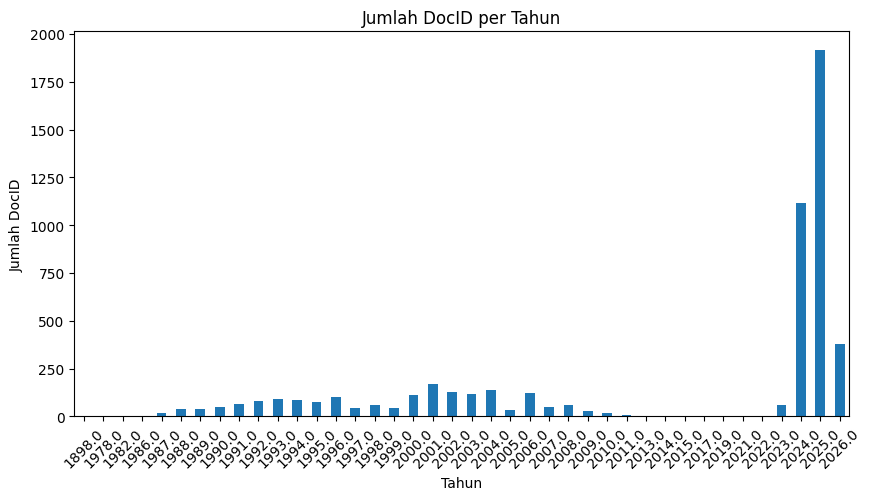

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dataset/dataset_step2_cleaned.csv", sep="|", encoding="utf-8")

# Buat kolom Decade (opsional, kalau mau grouping per dekade)
df["Decade"] = (df["Tahun"] // 10) * 10

# Hitung jumlah DocID per Tahun
docid_per_tahun = df.groupby("Tahun")["DocID"].count()

# Plot hasil
docid_per_tahun.plot(kind="bar", figsize=(10,5))
plt.title("Jumlah DocID per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Jumlah DocID")
plt.xticks(rotation=45)
plt.show()


<Axes: xlabel='Tahun'>

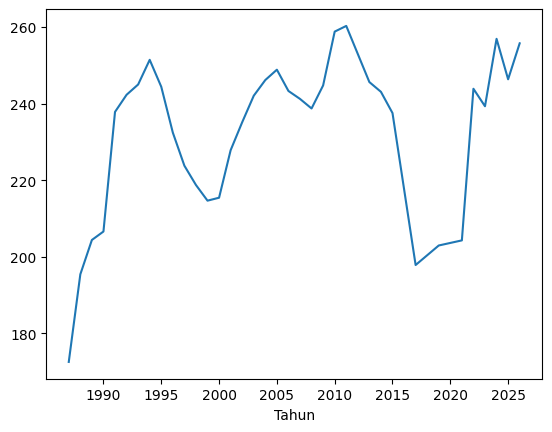

In [33]:
df.groupby("Tahun")["Word_Count"].mean().rolling(5).mean().plot()

# EXPERIMEN

In [34]:
import pandas as pd
import re

df = pd.read_csv("dataset/dataset_step2_cleaned.csv", sep="|")

# =========================
# 1. PROTECTED TOKENS
# =========================

PROTECTED = [
    r"\bDr\.",
    r"\bProf\.",
    r"\bM\.Si\b",
    r"\bS\.S\.I\b",
    r"\bPh\.D\b",
    r"\bU\.S\.",
    r"\bU\.K\.",
    r"\b[A-Z]{2,}\b",  # AI, NLP, WHO
]

def is_protected(text, idx):
    window = text[max(0, idx-15): idx+15]
    return any(re.search(p, window) for p in PROTECTED)

# =========================
# 2. MAIN DETECTOR (FOCUSED ON YOUR CASE)
# =========================

def detect_boundary_merge(text):
    text = str(text)

    # cari pola: titik langsung huruf kapital
    for m in re.finditer(r'\.([A-Z])', text):
        idx = m.start()

        # skip kalau protected
        if is_protected(text, idx):
            continue

        # ambil konteks sebelum titik
        before = text[max(0, idx-30):idx]

        # HEURISTIC 1: biasanya ada kata sebelum titik (word stuck)
        has_word_before = bool(re.search(r'[a-zA-Z]$', before))

        # HEURISTIC 2: setelah titik langsung kata panjang (bukan singkatan)
        after = text[idx+1:idx+15]
        next_word = re.match(r'[A-Z][a-z]+', after)

        if has_word_before and next_word:
            return True

    return False

# =========================
# 3. APPLY
# =========================

df["flag_boundary_merge"] = df["Paragraf"].apply(detect_boundary_merge)

# =========================
# 4. SAVE RESULT
# =========================

df[df["flag_boundary_merge"]].to_csv(
    "dataset/boundary_merge_errors.csv",
    index=False
)

print("DONE ✔ saved boundary_merge_errors.csv")
print(df["flag_boundary_merge"].value_counts())

DONE ✔ saved boundary_merge_errors.csv
flag_boundary_merge
False    5112
True      165
Name: count, dtype: int64


In [35]:
import pandas as pd
import re
import stanza

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("dataset/dataset_step2_cleaned.csv", sep="|")

# =========================
# INIT STANZA
# =========================
nlp = stanza.Pipeline(
    "id",
    processors="tokenize,pos,lemma,depparse",
    use_gpu=True
)

# =========================
# PROTECTED ENTITIES
# =========================
PROTECTED = [
    r"\bDr\.", r"\bProf\.",
    r"\bM\.Si\b", r"\bPh\.D\b",
    r"\bS\.S\.I\b",
    r"\bU\.S\.", r"\bU\.K\.",
    r"\b[A-Z]{2,}\b"
]

def is_protected(text, idx):
    window = text[max(0, idx-10): idx+10]
    return any(re.search(p, window) for p in PROTECTED)

# =========================
# FIX SENTENCE BOUNDARY
# =========================
def fix_boundary(text):
    text = str(text)

    def repl(m):
        idx = m.start()
        if is_protected(text, idx):
            return m.group(0)
        return ". " + m.group(1)

    return re.sub(r'\.([A-Z])', repl, text)

# =========================
# STANZA SENTENCE SPLIT
# =========================
def stanza_sent_split(text):
    doc = nlp(str(text))
    return [sent.text for sent in doc.sentences]

# =========================
# PIPELINE
# =========================
df["clean_text"] = df["Paragraf"].apply(fix_boundary)

df["sentences_stanza_dirty"] = df["Paragraf"].apply(stanza_sent_split)
df["sentences_stanza_clean"] = df["clean_text"].apply(stanza_sent_split)

df["sent_count_dirty"] = df["sentences_stanza_dirty"].apply(len)
df["sent_count_clean"] = df["sentences_stanza_clean"].apply(len)

df["sentence_gain"] = df["sent_count_clean"] - df["sent_count_dirty"]

# =========================
# FLAG ERROR
# =========================
df["flag_boundary_error"] = df["sentence_gain"] > 0

print("DONE ✔ STANZA PIPELINE FINISHED")
print(df["flag_boundary_error"].value_counts())

2026-06-19 23:05:58 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2026-06-19 23:05:59 INFO: Downloaded file to C:\Users\Danang ARA\stanza_resources\resources.json
2026-06-19 23:05:59 WARNING: Language id package default expects mwt, which has been added
2026-06-19 23:05:59 INFO: Loading these models for language: id (Indonesian):
| Processor | Package      |
----------------------------
| tokenize  | gsd          |
| mwt       | gsd          |
| pos       | gsd_charlm   |
| lemma     | gsd_nocharlm |
| depparse  | gsd_charlm   |

2026-06-19 23:05:59 INFO: Using device: cuda
2026-06-19 23:05:59 INFO: Loading: tokenize
2026-06-19 23:05:59 INFO: Loading: mwt
2026-06-19 23:05:59 INFO: Loading: pos
2026-06-19 23:06:01 INFO: Loading: lemma
2026-06-19 23:06:01 INFO: Loading: depparse
2026-06-19 23:06:01 INFO: Done loading processors!


KeyboardInterrupt: 

In [ ]:
# =========================
# SAVE OUTPUT
# =========================

output_path = "dataset/stanza_boundary_output.csv"
df.to_csv(output_path, index=False)

print(f"Saved to: {output_path}")

Saved to: dataset/stanza_boundary_output.csv
